# Notebook 1 (v4) - VelOT runtime: **GPU vs CPU-1 vs CPU-8 optimized multi-core**

**v4 fix.** The runtime regime dictionaries use the public key `name`, while the subprocess driver receives `condition`. The wrapper now maps `name → condition` explicitly and ignores harmless extra keys, so calls like `run_subprocess(seed=..., **reg)` work for all regimes.


**Goal.** Quantify how the VelOT pipeline scales on a single workstation across three
hardware regimes. The easy bifurcation synthetic dataset is held fixed; only the
device / CPU-core policy changes.

**Important correction in v3.** The previous CPU-8 condition used naive global
OpenMP/BLAS threading. For this small synthetic VelOT workload, most OT work is many
small Sinkhorn/window problems; forcing each small matrix operation to use 8 BLAS
threads can create oversubscription and overhead, making CPU-8 slower than CPU-1.
This version uses a **thread-aware CPU-8 policy**:

1. keep BLAS/OpenMP kernels serial (`OMP/MKL/OPENBLAS=1`) to avoid oversubscription;
2. parallelise independent VelOT OT window pairs across 8 CPU workers;
3. use 8 PyTorch intra-op threads for the neural smoothing stage;
4. keep all conditions in isolated subprocesses so thread settings are applied before
   NumPy / PyTorch / BLAS initialisation.

This makes the CPU-8 comparison a fair test of **useful multi-core parallelism** rather
than a test of naive BLAS oversubscription.

**Why subprocesses.** PyTorch / OpenMP thread settings and `CUDA_VISIBLE_DEVICES` cannot
be reset reliably inside a long-lived Jupyter kernel (BLAS initialises once on first
import). To get clean, reproducible measurements we spawn an isolated Python subprocess
for every measurement.

**What is measured.**

| Stage              | Origin in VelOT |
|--------------------|-----------------|
| `build_windows`    | `velot.tl.build_windows`        |
| `ot`               | `velot.tl.compute_ot_velocity`, or an equivalent threaded window-pair implementation for CPU-8 |
| `smooth`           | `velot.tl.smooth_velocity`      |
| `project_umap`     | `velot.tl.project_to_umap`      |
| `metrics`          | `velot.metrics.summary`         |

The same publication-ready figure layout is retained: runtime summary, quality
preservation, and representative velocity fields.


In [ ]:
from pathlib import Path
import os, sys, warnings, importlib.util, json, time, subprocess, warnings

warnings.filterwarnings("ignore")

REQUIRED_IMPORTS = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "scipy": "scipy",
    "anndata": "anndata",
    "scanpy": "scanpy",
    "ot": "POT",
    "torch": "torch",
}

missing = [
    pip_name
    for module_name, pip_name in REQUIRED_IMPORTS.items()
    if importlib.util.find_spec(module_name) is None
]

if missing:
    raise ImportError(
        "Missing packages:\n"
        + "\n".join(missing)
        + "\n\nInstall them manually with:\n"
        + f"pip install {' '.join(missing)}"
    )

# Import torch BEFORE velot
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Locate VelOT root
PROJECT_ROOT = Path.cwd().resolve()

CANDIDATES = [
    PROJECT_ROOT,
    PROJECT_ROOT.parent,
    PROJECT_ROOT.parent.parent,
]

VELOT_IMPORT_ROOT = None

for c in CANDIDATES:
    if (c / "velot").is_dir():
        VELOT_IMPORT_ROOT = c
        sys.path.insert(0, str(c))
        break

import velot

print(f"VelOT : {getattr(velot, '__version__', 'unknown')}")
print(f"Torch : {torch.__version__}")
print(f"CUDA  : {torch.cuda.is_available()}")
print(f"CWD   : {PROJECT_ROOT}")
print(f"VelOT import root: {VELOT_IMPORT_ROOT}")

VelOT : 0.1.0
Torch : 2.7.1+cu118
CUDA  : True
CWD   : /home/user/Documents/velot/notebooks/supplementary
VelOT import root: /home/user/Documents/velot


In [ ]:
# Publication style — Nature/NMETH defaults with a Wong colourblind-safe palette.
RUN_ROOT = PROJECT_ROOT / "results_velot_publication_v3_threads"
FIGDIR   = RUN_ROOT / "figures"
TABLEDIR = RUN_ROOT / "tables"
JSONDIR  = RUN_ROOT / "json"
for d in (FIGDIR, TABLEDIR, JSONDIR): d.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300,
    "savefig.bbox": "tight", "savefig.transparent": False,
    # "font.family": "serif",
    # "font.serif": ["DejaVu Serif", "Liberation Serif", "Times New Roman"],
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold",
    "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "legend.frameon": False, "legend.handlelength": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.8, "xtick.major.width": 0.8, "ytick.major.width": 0.8,
    "lines.linewidth": 1.2, "lines.markersize": 5,
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "axes.prop_cycle": plt.cycler("color",
        ["#0072B2","#D55E00","#009E73","#CC79A7","#F0E442","#56B4E9","#E69F00","#332288"]),
})

# Wong palette (colourblind-safe, used as named colours throughout)
WONG = {
    "blue":   "#0072B2", "orange": "#D55E00", "green":  "#009E73",
    "magenta":"#CC79A7", "yellow": "#F0E442", "skyblue":"#56B4E9",
    "amber":  "#E69F00", "purple": "#332288", "grey":   "#999999",
    "black":  "#000000", "red":    "#882255", "teal":   "#117733",
}

# Semantic colour roles
ROLE = {
    "gpu":      WONG["blue"],
    "cpu1":     WONG["orange"],
    "cpu8":     WONG["amber"],
    "baseline": WONG["green"],
    "ablation": WONG["purple"],
    "primary":  WONG["blue"],
    "secondary":WONG["magenta"],
    "accent":   WONG["green"],
    "neutral":  WONG["grey"],
    "Root":     WONG["grey"],
    "Branch_1": WONG["blue"],
    "Branch_2": WONG["orange"],
}

def panel_label(ax, letter, x=-0.18, y=1.05, fontsize=12, **kw):
    """Add a bold sans-serif (a)/(b)/(c) panel label in figure-corner style."""
    ax.text(x, y, letter, transform=ax.transAxes,
            fontsize=fontsize, fontweight="bold", va="bottom", ha="left",
            family="sans-serif", **kw)

def savefig_pdf(fig, stem, folder=None, close=False):
    """Save both PDF (vector, editable in Illustrator) and PNG (300 dpi)."""
    folder = Path(folder) if folder else FIGDIR
    folder.mkdir(parents=True, exist_ok=True)
    for ext in ("pdf", "png"):
        fig.savefig(folder / f"{stem}.{ext}", bbox_inches="tight")
    print(f"saved: {folder / stem}.{{pdf,png}}")
    if close: plt.close(fig)


def savefig(fig, stem, folder=None, close=False):
    """Save both PDF (vector, editable in Illustrator) and PNG (300 dpi)."""
    folder = Path(folder) if folder else FIGDIR
    folder.mkdir(parents=True, exist_ok=True)
    fig.savefig(folder / f"{stem}.png", bbox_inches="tight")
    print(f"saved: {folder / stem}.{{pdf,png}}")
    if close: plt.close(fig)


def add_significance_bracket(ax, x1, x2, y, text, color="black",
                              line_kw=None, text_kw=None):
    """Draw a horizontal significance bracket between x1 and x2 at y, with text above."""
    line_kw = {"lw": 0.9, "color": color, **(line_kw or {})}
    text_kw = {"ha": "center", "va": "bottom", "fontsize": 8,
               "color": color, **(text_kw or {})}
    dy = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02
    ax.plot([x1, x1, x2, x2], [y, y + dy, y + dy, y], **line_kw)
    ax.text((x1 + x2) / 2, y + dy * 1.1, text, **text_kw)

def stars(p):
    """ASA-style significance stars."""
    if   p < 1e-4: return "****"
    elif p < 1e-3: return "***"
    elif p < 1e-2: return "**"
    elif p < 5e-2: return "*"
    else:          return "ns"


In [ ]:
# Easy synthetic bifurcation — identical parameterisation to the working notebooks
# so that figures and timing here are directly comparable to those reports.
BASE_DENSITIES = {
    "root_density":     400,
    "root_position":    3.0,
    "branch_densities": (300, 400),
    "branch_positions": (5.0, 10.0),
    "branch_slopes":    (1.0, -1.0),
    "noise_level":      0.2,
    "extra_dimensions": 1,
    "n_neighbors":      50,
}
EDGES = [("Root", "Branch_1"), ("Root", "Branch_2")]
TERMINALS = ["Root", "Branch_1", "Branch_2"]

def build_easy_bifurcation(seed=42, density_scale=1.0,
                           noise_level=None, imbalance=None, n_neighbors=None):
    """Build the easy synthetic bifurcation used throughout these notebooks."""
    p = dict(BASE_DENSITIES)
    if noise_level is not None: p["noise_level"] = float(noise_level)
    if n_neighbors is not None: p["n_neighbors"] = int(n_neighbors)
    root = max(20, int(round(p["root_density"] * density_scale)))
    b1, b2 = p["branch_densities"]
    b1 = max(20, int(round(b1 * density_scale)))
    b2 = max(20, int(round(b2 * density_scale)))
    if imbalance is not None:
        b1 = max(20, int(round(b1 * float(imbalance))))
    adata = velot.datasets.synthetic_bifurcation(
        root_density=root, root_position=p["root_position"],
        branch_densities=(b1, b2), branch_positions=p["branch_positions"],
        branch_slopes=p["branch_slopes"], noise_level=p["noise_level"],
        extra_dimensions=p["extra_dimensions"], n_neighbors=p["n_neighbors"],
        seed=seed,
    )
    velot.pp.pseudotime(adata, key="true_pseudotime")
    adata.obs["clusters_id"]  = adata.obs["celltype"].cat.codes.astype(int)
    adata.obs["celltype_str"] = adata.obs["celltype"].astype(str)
    return adata

In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

def scalar_metrics_from_results(results):
    out = {k: float(results.get(k, np.nan))
           for k in ("iccoh_mean", "iccoh_median", "cbdir_mean", "cbdir_median")}
    out["quality_mean"] = float(np.nanmean([out["iccoh_mean"], out["cbdir_mean"]]))
    return out

def confidence_summary(adata):
    conf = np.asarray(adata.obs.get("velot_confidence",
                                    np.full(adata.n_obs, np.nan)), dtype=float)
    return {"confidence_mean":   float(np.nanmean(conf)),
            "confidence_median": float(np.nanmedian(conf)),
            "confidence_zero_frac": float(np.mean(conf <= 0))}

def future_alignment_score(adata, basis_key="X_pca",
                           velocity_key="velot_velocity_pca",
                           k=25, min_dt=0.01):
    """Local alignment of velocity to pseudotime-future neighbours."""
    X = np.asarray(adata.obsm[basis_key])
    V = np.asarray(adata.obsm[velocity_key])
    pt = np.asarray(adata.obs["true_pseudotime"].values, dtype=float)
    nn_ = NearestNeighbors(n_neighbors=min(max(k * 4, k + 1), adata.n_obs)).fit(X)
    _, idx = nn_.kneighbors(X)
    scores = []
    for i in range(adata.n_obs):
        cand = idx[i]; cand = cand[pt[cand] > pt[i] + min_dt]
        cand = cand[cand != i]
        if len(cand) == 0: continue
        cand = cand[:k]
        target = X[cand].mean(axis=0) - X[i]
        d = np.linalg.norm(target) * np.linalg.norm(V[i])
        if d > 1e-12:
            scores.append(float(np.dot(target, V[i]) / d))
    return float(np.nanmean(scores)) if scores else np.nan

def run_velot_once(name="baseline", seed=42, density_scale=1.0,
                   noise_level=None, imbalance=None,
                   basis="X_pca", spatial_key="clusters_id", n_clusters=None,
                   window_size=100, overlap_fraction=0.0, min_window_size=20,
                   reg=0.05, lambda_time=1.0, lambda_knn=1.0,
                   smooth=True, n_epochs=300, hidden_dim=128,
                   lambda_smooth=0.2, lambda_curl=0.2, lambda_divergence=0.0,
                   k_smooth=15, use_pseudotime=True, project_umap=True, verbose=False):
    """Run VelOT stage-by-stage; return (adata, record_dict, raw_metrics)."""
    adata = build_easy_bifurcation(seed=seed, density_scale=density_scale,
                                   noise_level=noise_level, imbalance=imbalance)
    times = {}
    def tic(stage):
        s = time.perf_counter()
        return lambda: times.__setitem__(stage, time.perf_counter() - s)

    stop = tic("build_windows")
    velot.tl.build_windows(adata, basis=basis, n_clusters=n_clusters,
                           window_size=window_size, overlap_fraction=overlap_fraction,
                           min_window_size=min_window_size, spatial_key=spatial_key,
                           random_state=seed); stop()

    stop = tic("ot")
    velot.tl.compute_ot_velocity(adata, basis=basis, reg=reg,
                                 lambda_time=lambda_time, lambda_knn=lambda_knn); stop()

    raw_key = "velot_velocity_raw_pca" if basis == "X_pca" else "velot_velocity_raw_umap"
    velocity_key_pca = raw_key

    if smooth:
        stop = tic("smooth")
        velot.tl.smooth_velocity(adata, basis=basis.split("X_")[1],
                                 velocity_key=raw_key, n_epochs=n_epochs,
                                 hidden_dim=hidden_dim, lambda_smooth=lambda_smooth,
                                 lambda_curl=lambda_curl, lambda_divergence=lambda_divergence,
                                 k_smooth=k_smooth, use_pseudotime=use_pseudotime,
                                 random_state=seed, verbose=verbose); stop()
        velocity_key_pca = "velot_velocity_pca" if basis == "X_pca" else "velot_velocity_umap"
    else:
        times["smooth"] = 0.0

    if project_umap and basis == "X_pca":
        stop = tic("project_umap")
        if smooth:
            velot.tl.project_to_umap(adata, "velot_velocity_pca", "velot_velocity_umap")
            velocity_key_umap = "velot_velocity_umap"
        else:
            velot.tl.project_to_umap(adata, "velot_velocity_raw_pca", "velot_velocity_raw_umap")
            velocity_key_umap = "velot_velocity_raw_umap"
        stop()
    elif basis == "X_umap":
        velocity_key_umap = velocity_key_pca; times["project_umap"] = 0.0
    else:
        velocity_key_umap = None;             times["project_umap"] = np.nan

    stop = tic("metrics")
    results = velot.metrics.summary(adata, cluster_edges=EDGES,
                                    cluster_key="celltype",
                                    embedding_key="X_umap",
                                    velocity_key=velocity_key_umap); stop()

    rec = dict(name=name, seed=seed, n_cells=int(adata.n_obs),
               basis=basis, spatial_key=str(spatial_key),
               n_clusters=n_clusters if n_clusters is not None else np.nan,
               window_size=int(window_size), overlap_fraction=float(overlap_fraction),
               reg=float(reg), lambda_time=float(lambda_time),
               lambda_knn=float(lambda_knn), smooth=bool(smooth),
               n_epochs=int(n_epochs), hidden_dim=int(hidden_dim),
               lambda_smooth=float(lambda_smooth), lambda_curl=float(lambda_curl),
               lambda_divergence=float(lambda_divergence),
               k_smooth=int(k_smooth), use_pseudotime=bool(use_pseudotime),
               n_window_pairs=int(adata.uns.get("velot_windows", {}).get("n_pairs", 0)),
               device=str(adata.uns.get("velot_smoothing", {}).get("device", "raw/no_smoothing")))
    rec.update({f"time_{k}": float(v) for k, v in times.items()})
    rec["time_total"] = float(np.nansum(list(times.values())))
    rec.update(scalar_metrics_from_results(results))
    rec.update(confidence_summary(adata))
    try:
        rec["future_alignment"] = future_alignment_score(
            adata, "X_pca",
            "velot_velocity_pca" if smooth else "velot_velocity_raw_pca")
    except Exception as e:
        rec["future_alignment"] = np.nan
        rec["future_alignment_error"] = str(e)
    return adata, rec, results


In [ ]:
def colour_for_celltype(labels):
    """Return per-cell colours using the semantic ROLE palette."""
    return np.array([ROLE.get(str(c), WONG["grey"]) for c in labels])

def scatter_embedding(ax, adata, basis="X_umap", color_key="celltype", s=8, alpha=0.85):
    X = np.asarray(adata.obsm[basis])
    labs = adata.obs[color_key].astype(str).values
    cols = colour_for_celltype(labs)
    ax.scatter(X[:, 0], X[:, 1], c=cols, s=s, lw=0, alpha=alpha, rasterized=True)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect("equal", adjustable="datalim")
    return ax

def quiver_panel(ax, adata, velocity_key="velot_velocity_umap",
                 basis="X_umap", color_key="celltype",
                 every=None, scale_mult=35.0,
                 width=0.0035, alpha=0.75, color="black", s=8):
    """Publication-grade velocity quiver panel."""
    X = np.asarray(adata.obsm[basis])
    V = np.asarray(adata.obsm[velocity_key])
    scatter_embedding(ax, adata, basis=basis, color_key=color_key, s=s, alpha=0.7)
    if every is None: every = max(1, adata.n_obs // 220)
    idx = np.arange(0, adata.n_obs, every)
    med = np.nanmedian(np.linalg.norm(V[idx], axis=1))
    scale = max(med * scale_mult, 1e-9)
    ax.quiver(X[idx, 0], X[idx, 1], V[idx, 0], V[idx, 1],
              angles="xy", scale_units="xy", scale=scale,
              width=width, alpha=alpha, color=color, linewidth=0.3, headwidth=4, headlength=5,)
    return ax

def streamline_panel(ax, adata, velocity_key="velot_velocity_umap",
                     basis="X_umap", color_key="celltype",
                     density=1.4, ngrid=40, lw=0.7, arrowsize=0.9, s=7):
    """Smoothed streamlines on a regular grid — nicer than quiver for trajectories."""
    from scipy.interpolate import griddata
    X = np.asarray(adata.obsm[basis]); V = np.asarray(adata.obsm[velocity_key])
    scatter_embedding(ax, adata, basis=basis, color_key=color_key, s=s, alpha=0.55)
    xmin, xmax = X[:, 0].min(), X[:, 0].max()
    ymin, ymax = X[:, 1].min(), X[:, 1].max()
    pad_x = (xmax - xmin) * 0.05; pad_y = (ymax - ymin) * 0.05
    gx = np.linspace(xmin - pad_x, xmax + pad_x, ngrid)
    gy = np.linspace(ymin - pad_y, ymax + pad_y, ngrid)
    GX, GY = np.meshgrid(gx, gy)
    U = griddata(X, V[:, 0], (GX, GY), method="linear")
    W_ = griddata(X, V[:, 1], (GX, GY), method="linear")
    speed = np.sqrt(U**2 + W_**2)
    if np.all(np.isnan(U)):
        return ax
    ax.streamplot(GX, GY, U, W_, density=density, linewidth=lw, arrowsize=arrowsize,
                  color="black", arrowstyle="->",
                  minlength=0.05)
    return ax

def celltype_legend(ax, loc="lower right", fontsize=7):
    handles = []
    for cat in TERMINALS:
        handles.append(plt.Line2D([0], [0], marker="o", color="w",
                                  markerfacecolor=ROLE.get(cat, WONG["grey"]),
                                  markersize=7, label=cat))
    ax.legend(handles=handles, loc=loc, fontsize=fontsize, frameon=False)


## 1. Hardware regimes and subprocess runner

The driver script runs one VelOT pipeline under an explicit thread policy.  The key
correction is the CPU-8 policy: instead of asking every BLAS kernel to use 8 threads
(which is inefficient for many small OT matrices), the notebook keeps BLAS serial and
uses 8 workers across independent OT window pairs plus 8 PyTorch threads during
smoothing.


In [7]:

SCALING_DIR = RUN_ROOT / "timing_subprocess"; SCALING_DIR.mkdir(parents=True, exist_ok=True)

runner_code = r"""
import argparse, json, os, sys, time
ap = argparse.ArgumentParser()
ap.add_argument("--out", required=True)
ap.add_argument("--condition", required=True)
ap.add_argument("--threads", type=int, required=True)
ap.add_argument("--torch-threads", type=int, default=None)
ap.add_argument("--blas-threads", type=int, default=None)
ap.add_argument("--ot-jobs", type=int, default=1)
ap.add_argument("--seed", type=int, required=True)
ap.add_argument("--n-epochs", type=int, default=300)
ap.add_argument("--hidden-dim", type=int, default=128)
ap.add_argument("--batch-size", type=int, default=256)
ap.add_argument("--window-size", type=int, default=100)
ap.add_argument("--overlap", type=float, default=0.0)
ap.add_argument("--project-root", required=True)
ap.add_argument("--warmup", action="store_true")
args = ap.parse_args()

# ---------------------------------------------------------------------
# Thread policy must be applied BEFORE importing numpy/torch/scipy/POT.
# For many small OT problems, multi-threaded BLAS is often slower than
# serial BLAS + task-level parallelism over independent window pairs.
# ---------------------------------------------------------------------
blas_threads = args.blas_threads if args.blas_threads is not None else args.threads
torch_threads = args.torch_threads if args.torch_threads is not None else args.threads
for k in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS",
          "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "BLIS_NUM_THREADS"):
    os.environ[k] = str(blas_threads)
os.environ["MKL_DYNAMIC"] = "FALSE"
os.environ["OMP_DYNAMIC"] = "FALSE"

sys.path.insert(0, args.project_root)

import numpy as np
import torch
import torch.nn as nn
torch.set_num_threads(max(1, int(torch_threads)))
try:
    # Keep inter-op low; we control task-level parallelism explicitly.
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

import velot

EDGES = [("Root", "Branch_1"), ("Root", "Branch_2")]

def build():
    a = velot.datasets.synthetic_bifurcation(
        root_density=400, root_position=3.0,
        branch_densities=(300, 400), branch_positions=(5.0, 10.0),
        branch_slopes=(1.0, -1.0), noise_level=0.2,
        extra_dimensions=1, n_neighbors=50, seed=args.seed)
    velot.pp.pseudotime(a, key="true_pseudotime")
    a.obs["clusters_id"] = a.obs["celltype"].cat.codes.astype(int)
    return a

def sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def time_stage(times, name, fn):
    sync()
    t0 = time.perf_counter()
    out = fn()
    sync()
    times[name] = time.perf_counter() - t0
    return out

def compute_ot_velocity_threaded(adata, basis="X_pca", reg=0.05,
                                 lambda_time=1.0, lambda_knn=1.0,
                                 n_jobs=1):
    # Thread-parallel equivalent of velot.tl.compute_ot_velocity.
    #
    # The computation is mathematically identical to the serial VelOT routine:
    # each independent window pair calls velot.tl._ot_velocity_pair, then results
    # are accumulated and averaged per source cell. It is used only to benchmark
    # useful CPU multi-core scaling without changing the VelOT output definition.
    if n_jobs <= 1:
        return velot.tl.compute_ot_velocity(
            adata, basis=basis, reg=reg,
            lambda_time=lambda_time, lambda_knn=lambda_knn)

    X = np.asarray(adata.obsm[basis])
    pseudotime = np.asarray(adata.obs["pseudotime"].values)
    window_pairs = list(adata.uns["velot_windows"]["pairs"])
    knn_adj = adata.obsp["connectivities"] if "connectivities" in adata.obsp else None
    n_cells, dim = adata.n_obs, X.shape[1]

    def one_pair(idx_src, idx_tgt):
        idx_src = np.asarray(idx_src, dtype=np.int64)
        idx_tgt = np.asarray(idx_tgt, dtype=np.int64)
        v_local = velot.tl._ot_velocity_pair(
            X, idx_src, idx_tgt, pseudotime, knn_adj,
            reg=reg, lambda_time=lambda_time, lambda_knn=lambda_knn)
        return idx_src, v_local

    try:
        from joblib import Parallel, delayed
        pair_results = Parallel(
            n_jobs=n_jobs, prefer="threads", require="sharedmem",
            batch_size=1, pre_dispatch="all")(
                delayed(one_pair)(idx_src, idx_tgt)
                for idx_src, idx_tgt in window_pairs)
    except Exception:
        from concurrent.futures import ThreadPoolExecutor
        with ThreadPoolExecutor(max_workers=n_jobs) as ex:
            futs = [ex.submit(one_pair, idx_src, idx_tgt)
                    for idx_src, idx_tgt in window_pairs]
            pair_results = [f.result() for f in futs]

    V = np.zeros((n_cells, dim), dtype=np.float64)
    counts = np.zeros(n_cells, dtype=np.float64)
    for idx_src, v_local in pair_results:
        np.add.at(V, idx_src, v_local)
        np.add.at(counts, idx_src, 1.0)

    mask = counts > 0
    V[mask] /= counts[mask, None]
    confidence = counts / (counts.max() if counts.max() > 0 else 1.0)

    if basis == "X_pca":
        adata.obsm["velot_velocity_raw_pca"] = V
    elif basis == "X_umap":
        adata.obsm["velot_velocity_raw_umap"] = V
    else:
        raise NotImplementedError(f"Unsupported basis: {basis}")

    adata.obs["velot_confidence"] = confidence
    print(f"  OT velocity computed: {int(mask.sum())} cells with velocity, "
          f"{int((~mask).sum())} cells without; threaded n_jobs={n_jobs}")
    return adata

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

n_epochs = args.n_epochs if not args.warmup else max(20, min(50, args.n_epochs // 5))
times = {}
t0_total = time.perf_counter()

a = build()

time_stage(times, "build_windows", lambda: velot.tl.build_windows(
    a, basis="X_pca", spatial_key="clusters_id",
    window_size=args.window_size, overlap_fraction=args.overlap,
    min_window_size=20, random_state=args.seed))

time_stage(times, "ot", lambda: compute_ot_velocity_threaded(
    a, basis="X_pca", reg=0.05, lambda_time=1.0, lambda_knn=1.0,
    n_jobs=max(1, int(args.ot_jobs))))

time_stage(times, "smooth", lambda: velot.tl.smooth_velocity(
    a, basis="pca", velocity_key="velot_velocity_raw_pca",
    n_epochs=n_epochs, hidden_dim=args.hidden_dim, batch_size=args.batch_size,
    lambda_smooth=0.2, lambda_curl=0.2, lambda_divergence=0.0,
    k_smooth=15, use_pseudotime=True, random_state=args.seed, verbose=False))

time_stage(times, "project_umap", lambda: velot.tl.project_to_umap(
    a, "velot_velocity_pca", "velot_velocity_umap"))

results = time_stage(times, "metrics", lambda: velot.metrics.summary(
    a, cluster_edges=EDGES, cluster_key="celltype",
    embedding_key="X_umap", velocity_key="velot_velocity_umap"))

sync()
total = time.perf_counter() - t0_total

rec = dict(
    condition=args.condition, threads=args.threads,
    blas_threads=int(blas_threads), torch_threads=int(torch_threads),
    ot_jobs=int(args.ot_jobs), seed=args.seed,
    n_cells=int(a.n_obs), n_epochs=int(n_epochs),
    hidden_dim=int(args.hidden_dim), batch_size=int(args.batch_size),
    window_size=int(args.window_size), overlap=float(args.overlap),
    torch_cuda_available=bool(torch.cuda.is_available()),
    velot_device=str(a.uns.get("velot_smoothing", {}).get("device", "unknown")),
    peak_gpu_mb=(torch.cuda.max_memory_allocated() / 1024**2
                 if torch.cuda.is_available() else None),
    n_window_pairs=int(a.uns.get("velot_windows", {}).get("n_pairs", 0)),
    time_total=float(total), warmup=bool(args.warmup),
    thread_policy=("serial-BLAS + threaded-OT + torch-threads"
                   if args.ot_jobs > 1 else "serial reference")
)
rec.update({f"time_{k}": float(v) for k, v in times.items()})
rec.update({k: float(results.get(k, np.nan))
            for k in ("iccoh_mean", "iccoh_median", "cbdir_mean", "cbdir_median")})
rec["quality_mean"] = float(np.nanmean([rec["iccoh_mean"], rec["cbdir_mean"]]))

with open(args.out, "w") as f:
    json.dump(rec, f, indent=2)

print(json.dumps({k: rec[k] for k in (
    "condition", "threads", "blas_threads", "torch_threads", "ot_jobs",
    "seed", "n_window_pairs", "time_total", "time_ot", "time_smooth",
    "iccoh_mean", "cbdir_mean", "peak_gpu_mb", "velot_device", "warmup"
)}, indent=2))
"""
runner_path = SCALING_DIR / "run_velot_once.py"
runner_path.write_text(runner_code)
print("Wrote driver:", runner_path)


Wrote driver: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3_threads/timing_subprocess/run_velot_once.py


## 2. Run the benchmark

`N_REPEATS` measurement repetitions per regime, plus one warm-up that is discarded.

The timing workload remains the same easy bifurcation simulation, but the windowing
configuration is chosen to create enough independent OT window pairs for a meaningful
multi-core comparison. The CPU-8 condition therefore tests task-level parallelism over
VelOT windows, while CPU-1 is the serial reference.


In [ ]:
N_REPEATS  = 5
N_EPOCHS   = 400
HIDDEN_DIM = 256
BATCH_SIZE = 512

# More overlapping windows make the easy simulation a meaningful test for 8 CPU workers.
# The dataset is unchanged; only the number of local OT tasks is increased.
WINDOW_SIZE = 80
OVERLAP     = 0.50

SEEDS = list(range(42, 42 + N_REPEATS))

# Identify VelOT import root for the subprocess
for c in CANDIDATES:
    if (c / "velot").is_dir():
        VELOT_IMPORT_ROOT = c
        break
else:
    VELOT_IMPORT_ROOT = PROJECT_ROOT

REGIMES = [
    # CPU-1: strict serial reference.
    dict(name="CPU-1", threads=1, torch_threads=1, blas_threads=1,
         ot_jobs=1, hide_cuda=True),

    # CPU-8: useful multi-core policy.
    # BLAS is kept serial because the OT matrices are small; the independent
    # VelOT window pairs are distributed across workers and the MLP smoother
    # uses 8 PyTorch intra-op threads.
    dict(name="CPU-8", threads=8, torch_threads=8, blas_threads=1,
         ot_jobs=8, hide_cuda=True),
]
if torch.cuda.is_available():
    # GPU uses CUDA for the MLP smoother; keep CPU BLAS serial and parallelise
    # OT windows so CPU preprocessing does not become the bottleneck.
    REGIMES.insert(0, dict(name="GPU", threads=8, torch_threads=1,
                           blas_threads=1, ot_jobs=8, hide_cuda=False))

def run_subprocess(*, name=None, condition=None, threads=1,
                   torch_threads=1, blas_threads=1, ot_jobs=1,
                   seed=42, hide_cuda=True, warmup=False, **unused_kwargs):
    """Run one isolated VelOT timing subprocess.

    REGIMES uses the human-readable key ``name`` because the plotting code
    also consumes it. The command-line driver expects ``condition``. This
    wrapper accepts both, maps ``name`` to ``condition`` when needed, and
    ignores harmless extra metadata keys so future regime dictionaries do not
    break the benchmark loop.
    """
    if condition is None:
        condition = name
    if condition is None:
        raise ValueError("run_subprocess requires either 'condition' or 'name'.")
    out = SCALING_DIR / (
        f"{condition}_seed{seed}{'_warmup' if warmup else ''}.json")

    env = os.environ.copy()
    for k in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS",
              "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "BLIS_NUM_THREADS"):
        env[k] = str(blas_threads)
    env["MKL_DYNAMIC"] = "FALSE"
    env["OMP_DYNAMIC"] = "FALSE"
    env["PYTHONHASHSEED"] = str(seed)
    if hide_cuda:
        env["CUDA_VISIBLE_DEVICES"] = ""

    cmd = [sys.executable, str(runner_path),
           "--out", str(out),
           "--condition", condition,
           "--threads", str(threads),
           "--torch-threads", str(torch_threads),
           "--blas-threads", str(blas_threads),
           "--ot-jobs", str(ot_jobs),
           "--seed", str(seed),
           "--n-epochs", str(N_EPOCHS),
           "--hidden-dim", str(HIDDEN_DIM),
           "--batch-size", str(BATCH_SIZE),
           "--window-size", str(WINDOW_SIZE),
           "--overlap", str(OVERLAP),
           "--project-root", str(VELOT_IMPORT_ROOT)]
    if warmup:
        cmd.append("--warmup")

    print("RUN:", " ".join(map(str, cmd)))
    subprocess.run(cmd, check=True, env=env)
    with open(out) as f:
        return json.load(f)

In [ ]:
records = []
for reg in REGIMES:
    reg_args = dict(reg)  # defensive copy: REGIMES is reused by plotting cells
    # warm-up run discarded from benchmark tables
    _ = run_subprocess(seed=SEEDS[0], warmup=True, **reg_args)
    for seed in SEEDS:
        records.append(run_subprocess(seed=seed, warmup=False, **reg_args))

bench = pd.DataFrame(records)
bench.to_csv(TABLEDIR / "nb1_v3_raw_timings.csv", index=False)

In [10]:
bench = pd.read_csv(TABLEDIR / "nb1_v3_raw_timings.csv")

In [11]:
# Convenience columns for plotting and sanity checks.
cpu1_med = bench.loc[bench.condition.eq("CPU-1"), "time_total"].median()
bench["speedup_vs_cpu1"] = cpu1_med / bench["time_total"]
bench["ot_speedup_vs_cpu1"] = (
    bench.loc[bench.condition.eq("CPU-1"), "time_ot"].median() / bench["time_ot"]
)

display_cols = ["condition", "seed", "threads", "blas_threads", "torch_threads",
                "ot_jobs", "n_window_pairs", "time_total", "time_ot",
                "time_smooth", "speedup_vs_cpu1", "cbdir_mean",
                "iccoh_mean", "quality_mean", "velot_device"]
bench[display_cols].round(4)

,condition,seed,threads,blas_threads,torch_threads,ot_jobs,n_window_pairs,time_total,time_ot,time_smooth,speedup_vs_cpu1,cbdir_mean,iccoh_mean,quality_mean,velot_device
0,GPU,42,8,1,1,8,24,19.8218,0.3790,3.4373,2.4321,0.9130,0.9425,0.9277,cuda
1,GPU,43,8,1,1,8,24,17.9914,0.2316,2.8343,2.6795,0.8425,0.9579,0.9002,cuda
2,GPU,44,8,1,1,8,24,17.1324,0.2626,2.7825,2.8139,0.8978,0.9520,0.9249,cuda
3,GPU,45,8,1,1,8,24,19.9694,0.3659,4.3238,2.4141,0.8959,0.9667,0.9313,cuda
4,GPU,46,8,1,1,8,24,19.9199,0.3766,3.4145,2.4201,0.8825,0.9610,0.9217,cuda
5,CPU-1,42,1,1,1,1,24,50.3669,0.2582,36.2550,0.9571,0.9143,0.9420,0.9282,cpu
6,CPU-1,43,1,1,1,1,24,48.2087,0.1902,32.2888,1.0000,0.8422,0.9583,0.9003,cpu
7,CPU-1,44,1,1,1,1,24,48.5134,0.2131,33.2846,0.9937,0.8985,0.9518,0.9251,cpu
8,CPU-1,45,1,1,1,1,24,47.4116,0.2130,32.4352,1.0168,0.8955,0.9667,0.9311,cpu
9,CPU-1,46,1,1,1,1,24,47.7859,0.2551,32.3407,1.0088,0.8821,0.9601,0.9211,cpu


## 3. Per-regime summary table

Stage timings, total wall-clock, speed-up and quality means with standard deviations
across seeds.  The table also records the explicit thread policy used by each regime.


In [12]:
stage_cols = [c for c in bench.columns if c.startswith("time_") and c != "time_total"]
agg_cols = ["time_total", "speedup_vs_cpu1", "ot_speedup_vs_cpu1"] + stage_cols + ["cbdir_mean", "iccoh_mean",
                                            "quality_mean", "peak_gpu_mb", "n_window_pairs"]
summary = bench.groupby("condition")[agg_cols].agg(["mean", "std"])
summary.columns = [f"{a}_{b}" for a, b in summary.columns]
summary = summary.reset_index()
summary.to_csv(TABLEDIR / "nb1_v3_summary.csv", index=False)
summary.round(3)

,condition,time_total_mean,time_total_std,speedup_vs_cpu1_mean,speedup_vs_cpu1_std,ot_speedup_vs_cpu1_mean,ot_speedup_vs_cpu1_std,time_build_windows_mean,time_build_windows_std,time_ot_mean,...,cbdir_mean_mean,cbdir_mean_std,iccoh_mean_mean,iccoh_mean_std,quality_mean_mean,quality_mean_std,peak_gpu_mb_mean,peak_gpu_mb_std,n_window_pairs_mean,n_window_pairs_std
0,CPU-1,48.457,1.146,0.995,0.023,0.956,0.125,0.001,0.0,0.226,...,0.887,0.027,0.956,0.009,0.921,0.012,NaN,NaN,24.0,0.0
1,CPU-8,32.065,0.454,1.504,0.022,0.722,0.100,0.001,0.0,0.299,...,0.887,0.027,0.956,0.009,0.921,0.012,NaN,NaN,24.0,0.0
2,GPU,18.967,1.319,2.552,0.184,0.688,0.167,0.001,0.0,0.323,...,0.886,0.027,0.956,0.009,0.921,0.012,79.919,0.0,24.0,0.0


## 4. Composite Figure 1 - runtime comparison

The same six-panel composite is retained:

- **(a)** Total wall-clock per regime — bars ± SD, with per-replicate dots overlaid.
- **(b)** Stage breakdown — horizontal stacked bars (proportions add to total).
- **(c)** Stage timing distributions — strip plot across replicates.
- **(d)** Speed-up vs CPU-1 — log-scale, with annotated factors.
- **(e)** Per-replicate trajectories — total time as a function of replicate index.
- **(f)** GPU memory footprint — peak allocated MiB during smoothing.

In v3 the CPU-8 bar represents the optimized multi-core policy: serial BLAS, parallel
OT window pairs and 8 PyTorch CPU threads.


saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3_threads/figures/nb1_v3_master_timing.{pdf,png}


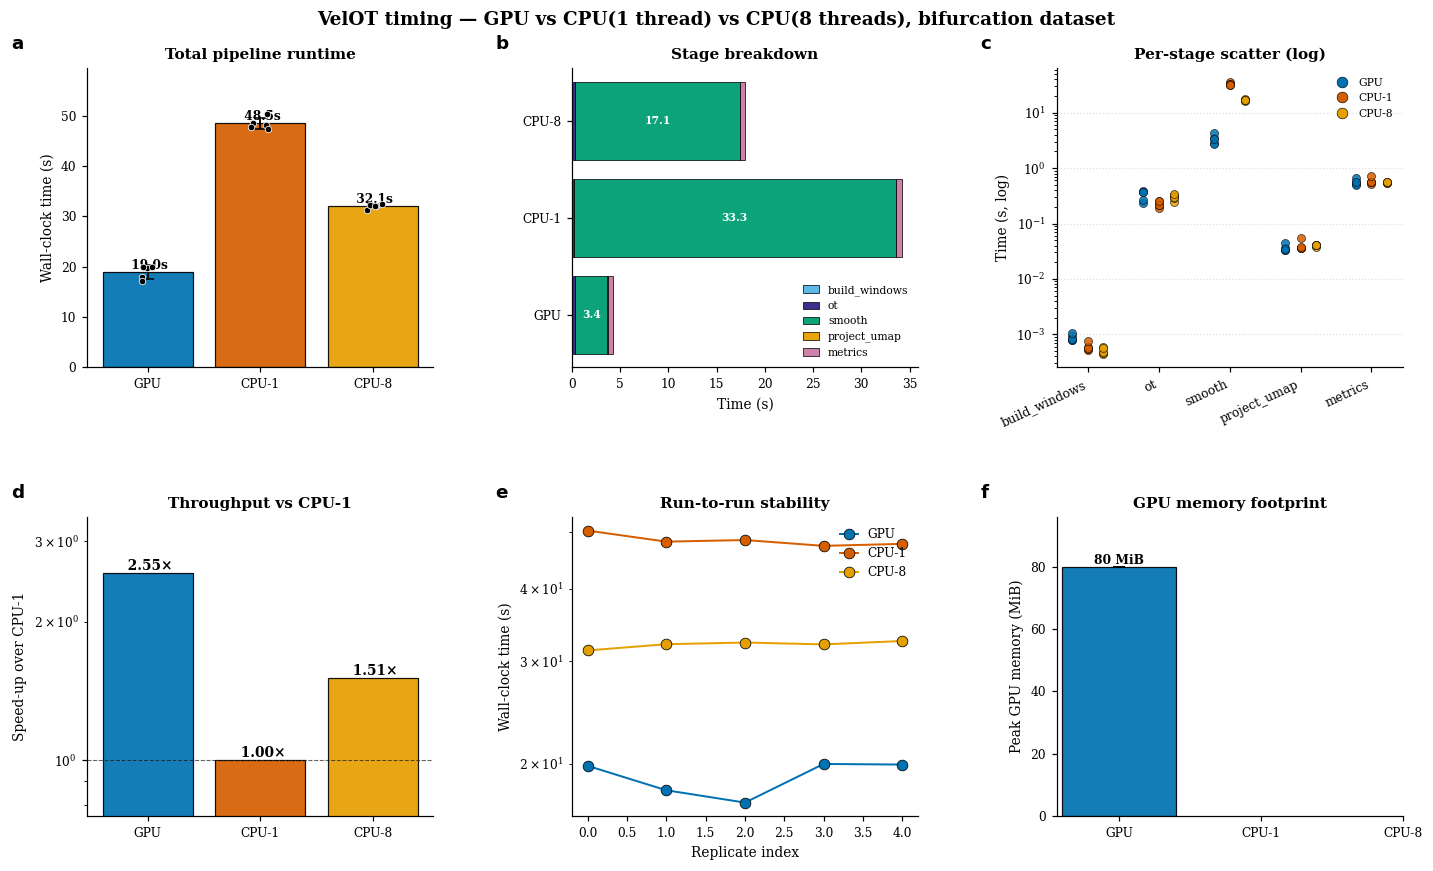

In [12]:
from matplotlib import gridspec
order = [r["name"] for r in REGIMES]
colour = {"GPU": ROLE["gpu"], "CPU-1": ROLE["cpu1"], "CPU-8": ROLE["cpu8"]}

fig = plt.figure(figsize=(13.0, 8.0))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.40,
                        left=0.06, right=0.98, top=0.93, bottom=0.08)

# ---------- (a) total wall-clock ----------
ax = fig.add_subplot(gs[0, 0])
panel_label(ax, "a", x=-0.22)
g = bench.groupby("condition")["time_total"].agg(["mean", "std"]).reindex(order)
xs = np.arange(len(order))
bars = ax.bar(xs, g["mean"], yerr=g["std"], capsize=4,
              color=[colour[c] for c in order],
              edgecolor="black", linewidth=0.8, alpha=0.92)
for i, cond in enumerate(order):
    pts = bench.loc[bench["condition"].eq(cond), "time_total"].values
    ax.scatter(np.full(len(pts), i) + np.random.uniform(-0.10, 0.10, len(pts)),
               pts, color="black", s=18, zorder=5, edgecolor="white", linewidth=0.5)
for bar, m in zip(bars, g["mean"]):
    ax.text(bar.get_x() + bar.get_width()/2, m, f" {m:.1f}s",
            ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_xticks(xs); ax.set_xticklabels(order)
ax.set_ylabel("Wall-clock time (s)")
ax.set_title("Total pipeline runtime")
ax.margins(y=0.18)

# ---------- (b) stage stacked bars (horizontal) ----------
ax = fig.add_subplot(gs[0, 1])
panel_label(ax, "b", x=-0.22)
stage_names = ["build_windows", "ot", "smooth", "project_umap", "metrics"]
stage_colors = [WONG["skyblue"], WONG["purple"], WONG["green"],
                WONG["amber"], WONG["magenta"]]
piv = bench.groupby("condition")[[f"time_{s}" for s in stage_names]].mean().reindex(order)
left = np.zeros(len(order))
for s, c in zip(stage_names, stage_colors):
    vals = piv[f"time_{s}"].values
    ax.barh(xs, vals, left=left, color=c, edgecolor="black",
            linewidth=0.5, label=s, alpha=0.95)
    for i, v in enumerate(vals):
        if v > 0.8:
            ax.text(left[i] + v/2, i, f"{v:.1f}",
                    ha="center", va="center", fontsize=7,
                    color="white", fontweight="bold")
    left += vals
ax.set_yticks(xs); ax.set_yticklabels(order)
ax.set_xlabel("Time (s)")
ax.set_title("Stage breakdown")
ax.legend(loc="lower right", fontsize=7, ncol=1)

# ---------- (c) stage distributions ----------
ax = fig.add_subplot(gs[0, 2])
panel_label(ax, "c", x=-0.22)
long_df = bench.melt(id_vars=["condition", "seed"],
                     value_vars=[f"time_{s}" for s in stage_names],
                     var_name="stage", value_name="seconds")
long_df["stage"] = long_df["stage"].str.replace("time_", "")
for i, s in enumerate(stage_names):
    for j, cond in enumerate(order):
        ys = long_df.query("stage == @s and condition == @cond")["seconds"].values
        ax.scatter(np.full(len(ys), i + (j - 1) * 0.22),
                   ys, color=colour[cond], s=28,
                   edgecolor="black", linewidth=0.4, alpha=0.85)
ax.set_yscale("log")
ax.set_xticks(range(len(stage_names)))
ax.set_xticklabels(stage_names, rotation=25, ha="right")
ax.set_ylabel("Time (s, log)")
ax.set_title("Per-stage scatter (log)")
handles = [plt.Line2D([0],[0], marker="o", color="w",
                      markerfacecolor=colour[c], markersize=7,
                      label=c, markeredgecolor="black", markeredgewidth=0.4)
           for c in order]
ax.legend(handles=handles, loc="upper right", fontsize=7)
ax.grid(axis="y", ls=":", alpha=0.4)

# ---------- (d) speed-up vs CPU-1 ----------
ax = fig.add_subplot(gs[1, 0])
panel_label(ax, "d", x=-0.22)
base = g.loc["CPU-1", "mean"]
speed = base / g["mean"]
bars = ax.bar(xs, speed.values, color=[colour[c] for c in order],
              edgecolor="black", linewidth=0.8, alpha=0.92)
ax.axhline(1, ls="--", color="black", lw=0.7, alpha=0.6)
for bar, v in zip(bars, speed.values):
    ax.text(bar.get_x() + bar.get_width()/2, v, f" {v:.2f}×",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_xticks(xs); ax.set_xticklabels(order)
ax.set_ylabel("Speed-up over CPU-1")
ax.set_yscale("log")
ax.set_title("Throughput vs CPU-1")
ax.margins(y=0.30)
ax.grid(axis="y", ls=":", alpha=0.4)

# ---------- (e) per-replicate trajectories ----------
ax = fig.add_subplot(gs[1, 1])
panel_label(ax, "e", x=-0.22)
for cond in order:
    s = bench.loc[bench["condition"].eq(cond)].sort_values("seed")
    ax.plot(range(len(s)), s["time_total"].values, "o-",
            color=colour[cond], label=cond, lw=1.3, ms=7,
            markeredgecolor="black", markeredgewidth=0.5)
ax.set_xlabel("Replicate index"); ax.set_ylabel("Wall-clock time (s)")
ax.set_title("Run-to-run stability")
ax.set_yscale("log")
ax.legend(loc="best")
ax.grid(axis="y", ls=":", alpha=0.4)

# ---------- (f) GPU memory ----------
ax = fig.add_subplot(gs[1, 2])
panel_label(ax, "f", x=-0.22)
mem = bench.dropna(subset=["peak_gpu_mb"])
if len(mem):
    g_mem = mem.groupby("condition")["peak_gpu_mb"].agg(["mean", "std"]).reindex(order)
    mask = ~g_mem["mean"].isna()
    xs2 = np.where(mask.values)[0]
    bars = ax.bar(xs2, g_mem["mean"][mask], yerr=g_mem["std"][mask],
                  capsize=4, color=[colour[c] for c in g_mem.index[mask]],
                  edgecolor="black", linewidth=0.8, alpha=0.92)
    for bar, v in zip(bars, g_mem["mean"][mask].values):
        ax.text(bar.get_x() + bar.get_width()/2, v, f"{v:.0f} MiB",
                ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_xticks(xs); ax.set_xticklabels(order)
    ax.set_ylabel("Peak GPU memory (MiB)")
    ax.set_title("GPU memory footprint")
    ax.margins(y=0.20)
else:
    ax.text(0.5, 0.5, "No GPU available\nin this run",
            ha="center", va="center", transform=ax.transAxes,
            fontsize=10, color="grey")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title("GPU memory footprint")

fig.suptitle("VelOT timing — GPU vs CPU(1 thread) vs CPU(8 threads), bifurcation dataset",
             fontsize=12, fontweight="bold", y=0.995)
savefig(fig, "nb1_v3_master_timing")
plt.show()

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3_threads/figures/ablation_time_a.{pdf,png}


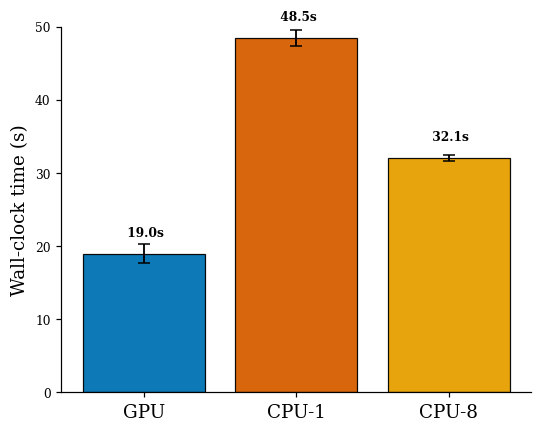

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3_threads/figures/ablation_time_b.{pdf,png}


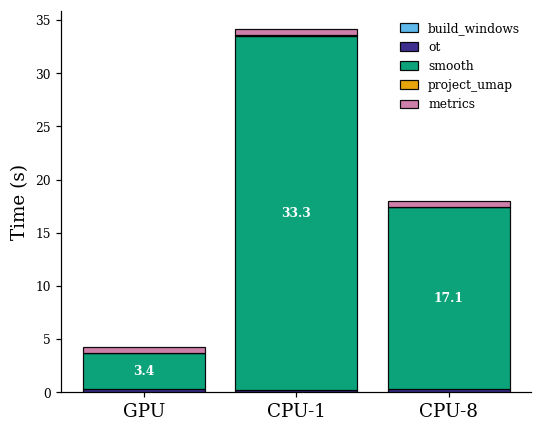

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3_threads/figures/ablation_time_c.{pdf,png}


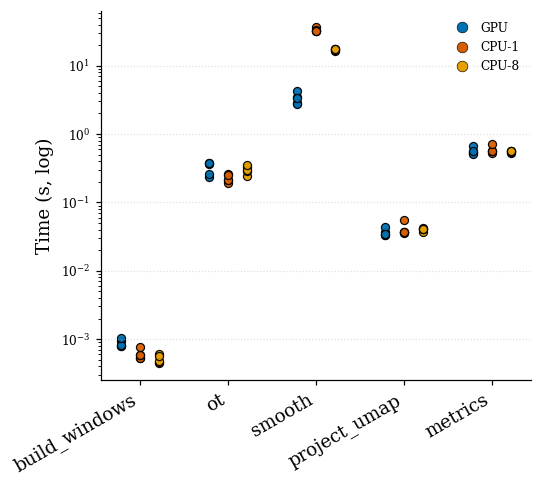

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3_threads/figures/ablation_time_d.{pdf,png}


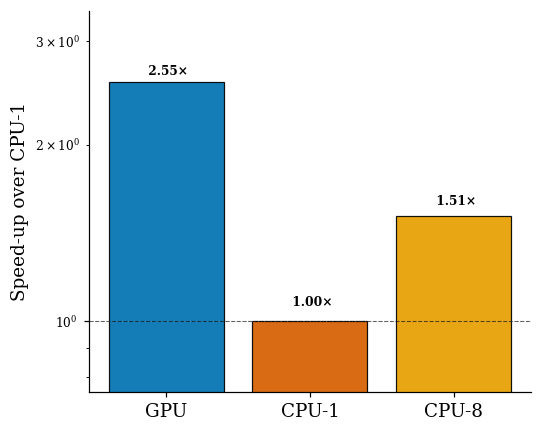

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3_threads/figures/ablation_time_e.{pdf,png}


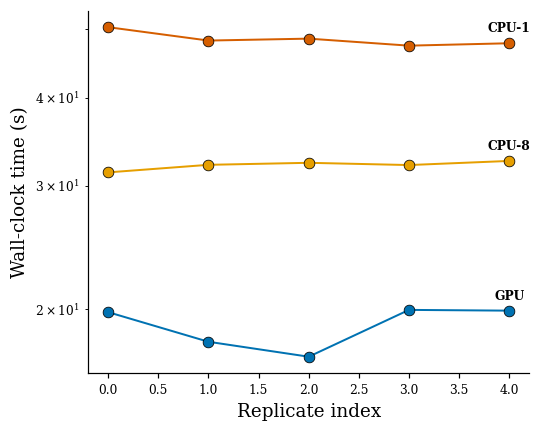

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3_threads/figures/ablation_time_f.{pdf,png}


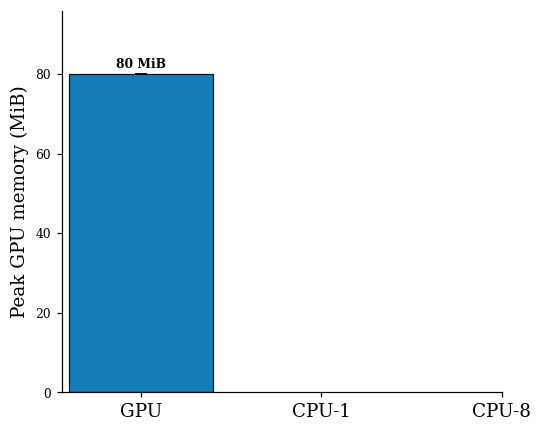

In [51]:
order = [r["name"] for r in REGIMES]
colour = {"GPU": ROLE["gpu"], "CPU-1": ROLE["cpu1"], "CPU-8": ROLE["cpu8"]}
g = bench.groupby("condition")["time_total"].agg(["mean", "std"]).reindex(order)
xs = np.arange(len(order))

# ---------- (a) total wall-clock ----------
fig, ax = plt.subplots(figsize=(5,4))
bars = ax.bar(xs, g["mean"], yerr=g["std"], capsize=4,
              color=[colour[c] for c in order],
              edgecolor="black", linewidth=0.8, alpha=0.95)
# for i, cond in enumerate(order):
#     pts = bench.loc[bench["condition"].eq(cond), "time_total"].values
#     ax.scatter(np.full(len(pts), i) + np.random.uniform(-0.10, 0.10, len(pts)),
#                pts, color="black", s=18, zorder=5, edgecolor="white", linewidth=0.5)
for bar, m in zip(bars, g["mean"]):
    ax.text(bar.get_x() + bar.get_width()/2, m+2, f" {m:.1f}s",
            ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_xticks(xs)
ax.set_xticklabels(order, fontsize=12)
ax.set_ylabel("Wall-clock time (s)", fontsize=12)
ax.set_ylim(0,50)
# ax.set_title("Total pipeline runtime")
ax.margins(y=0.18)
plt.tight_layout()
savefig(fig, "ablation_time_a")
# fig.savefig("figure_a.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# ---------- (b) stage stacked bars (vertical) ----------
fig, ax = plt.subplots(figsize=(5.0, 4.0))
stage_names = ["build_windows", "ot", "smooth", "project_umap", "metrics"]
stage_colors = [WONG["skyblue"], WONG["purple"], WONG["green"],
                WONG["amber"], WONG["magenta"]]
piv = bench.groupby("condition")[[f"time_{s}" for s in stage_names]].mean().reindex(order)
bottom = np.zeros(len(order))
for s, c in zip(stage_names, stage_colors):
    vals = piv[f"time_{s}"].values
    ax.bar(xs, vals, bottom=bottom, color=c, edgecolor="black",
           linewidth=0.8, label=s, alpha=0.95)
    for i, v in enumerate(vals):
        if v > 0.8:
            ax.text(i, bottom[i] + v/2, f"{v:.1f}",
                    ha="center", va="center", fontsize=8,
                    color="white", fontweight="bold")
    bottom += vals
ax.set_xticks(xs)
ax.set_xticklabels(order, fontsize=12)
ax.set_ylabel("Time (s)", fontsize=12)
# ax.set_title("Stage breakdown")
ax.legend(loc="upper right", fontsize=8, ncol=1)
plt.tight_layout()
# fig.savefig("figure_b.png", dpi=300, bbox_inches="tight", facecolor="white")
savefig(fig, "ablation_time_b")
plt.show()

# ---------- (c) stage distributions ----------
fig, ax = plt.subplots(figsize=(5.0, 4.5))
long_df = bench.melt(id_vars=["condition", "seed"],
                     value_vars=[f"time_{s}" for s in stage_names],
                     var_name="stage", value_name="seconds")
long_df["stage"] = long_df["stage"].str.replace("time_", "")
for i, s in enumerate(stage_names):
    for j, cond in enumerate(order):
        ys = long_df.query("stage == @s and condition == @cond")["seconds"].values
        ax.scatter(np.full(len(ys), i + (j - 1) * 0.22),
                   ys, color=colour[cond], s=28,
                   edgecolor="black", linewidth=0.8, alpha=0.95)
ax.set_yscale("log")
ax.set_xticks(range(len(stage_names)))
ax.set_xticklabels(stage_names, fontsize=12, rotation=30, ha="right")
ax.set_ylabel("Time (s, log)", fontsize=12)
# ax.set_title("Per-stage scatter (log)")
handles = [plt.Line2D([0],[0], marker="o", color="w",
                      markerfacecolor=colour[c], markersize=7,
                      label=c, markeredgecolor="black", markeredgewidth=0.4)
           for c in order]
ax.legend(handles=handles, loc="upper right", fontsize=8)
ax.grid(axis="y", ls=":", alpha=0.4)
plt.tight_layout()
# fig.savefig("figure_c.png", dpi=300, bbox_inches="tight", facecolor="white")
savefig(fig, "ablation_time_c")
plt.show()

# ---------- (d) speed-up vs CPU-1 ----------
fig, ax = plt.subplots(figsize=(5,4))
base = g.loc["CPU-1", "mean"]
speed = base / g["mean"]
bars = ax.bar(xs, speed.values, color=[colour[c] for c in order],
              edgecolor="black", linewidth=0.8, alpha=0.92)
ax.axhline(1, ls="--", color="black", lw=0.7, alpha=0.6)
for bar, v in zip(bars, speed.values):
    ax.text(bar.get_x() + bar.get_width()/2, v+0.05, f" {v:.2f}×",
            ha="center", va="bottom", fontsize=8, fontweight="bold")
# ax.set_ylim(0,3000)
ax.set_xticks(xs)
ax.set_xticklabels(order, fontsize=12)
ax.set_ylabel("Speed-up over CPU-1", fontsize=12)
ax.set_yscale("log")
# ax.set_title("Throughput vs CPU-1")
ax.margins(y=0.30)
ax.grid(axis="y", ls=":", alpha=0.4)
plt.tight_layout()
# fig.savefig("figure_d.png", dpi=300, bbox_inches="tight", facecolor="white")
savefig(fig, "ablation_time_d")
plt.show()

# ---------- (e) per-replicate trajectories ----------
fig, ax = plt.subplots(figsize=(5,4))
for cond in order:
    s = bench.loc[bench["condition"].eq(cond)].sort_values("seed")
    xs_rep = range(len(s))
    ys_rep = s["time_total"].values
    ax.plot(xs_rep, ys_rep, "o-",
            color=colour[cond], label=cond, lw=1.3, ms=7,
            markeredgecolor="black", markeredgewidth=0.5)
    ax.text(list(xs_rep)[-1], ys_rep[-1]*1.05, cond,
            ha="center", va="center", fontsize=8,
            fontweight="bold", color="black") #colour[cond])
ax.set_xlabel("Replicate index", fontsize=12)
ax.set_ylabel("Wall-clock time (s)", fontsize=12)
# ax.set_title("Run-to-run stability")
ax.set_yscale("log")
# ax.legend(loc="best")
# ax.legend(
#     loc="center right",
#     bbox_to_anchor=(1.0, 0.7),
#     fontsize=8
# )
ax.grid(axis="y", ls=":", alpha=0.4)
plt.tight_layout()
# fig.savefig("figure_e.png", dpi=300, bbox_inches="tight", facecolor="white")
savefig(fig, "ablation_time_e")
plt.show()

# ---------- (f) GPU memory ----------
fig, ax = plt.subplots(figsize=(5,4))
mem = bench.dropna(subset=["peak_gpu_mb"])
if len(mem):
    g_mem = mem.groupby("condition")["peak_gpu_mb"].agg(["mean", "std"]).reindex(order)
    mask = ~g_mem["mean"].isna()
    xs2 = np.where(mask.values)[0]
    bars = ax.bar(xs2, g_mem["mean"][mask], yerr=g_mem["std"][mask],
                  capsize=4, color=[colour[c] for c in g_mem.index[mask]],
                  edgecolor="black", linewidth=0.8, alpha=0.92)
    for bar, v in zip(bars, g_mem["mean"][mask].values):
        ax.text(bar.get_x() + bar.get_width()/2, v+1, f"{v:.0f} MiB",
                ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_xticks(xs)
    ax.set_xticklabels(order, fontsize=12)
    ax.set_ylabel("Peak GPU memory (MiB)", fontsize=12)
    # ax.set_title("GPU memory footprint")
    ax.margins(y=0.20)
else:
    ax.text(0.5, 0.5, "No GPU available\nin this run",
            ha="center", va="center", transform=ax.transAxes,
            fontsize=10, color="grey")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title("GPU memory footprint")
plt.tight_layout()
# fig.savefig("figure_f.png", dpi=300, bbox_inches="tight", facecolor="white")
savefig(fig, "ablation_time_f")
plt.show()

## 5. Composite Figure 2 - velocity-quality preservation

Faster runs are only useful if they do not degrade velocity quality. We compare CBDir,
ICCoh and the composite quality across regimes with **Kruskal–Wallis** (omnibus) and
**pairwise Mann–Whitney U** tests (with Benjamini–Hochberg correction).

In [10]:

from scipy import stats as scst
from itertools import combinations

def bh(p):
    p = np.asarray(p, dtype=float); n = len(p)
    order = np.argsort(p); ranked = p[order] * n / np.arange(1, n+1)
    q_sorted = np.minimum.accumulate(ranked[::-1])[::-1]
    q = np.empty(n); q[order] = np.clip(q_sorted, 0, 1)
    return q

stat_rows = []
for metric in ("cbdir_mean", "iccoh_mean", "quality_mean"):
    groups = [bench.loc[bench["condition"].eq(c), metric].dropna().values for c in order]
    if all(len(g) > 0 for g in groups):
        H, p_kw = scst.kruskal(*groups)
        for (i, j) in combinations(range(len(order)), 2):
            U, p_mw = scst.mannwhitneyu(groups[i], groups[j], alternative="two-sided")
            stat_rows.append(dict(metric=metric, comparison=f"{order[i]} vs {order[j]}",
                                  U=U, p_raw=p_mw))
        stat_rows.append(dict(metric=metric, comparison="omnibus KW",
                              U=H, p_raw=p_kw))
stat_df = pd.DataFrame(stat_rows)
stat_df["p_bh"] = np.nan
for m in stat_df["metric"].unique():
    mask = stat_df["metric"].eq(m)
    stat_df.loc[mask, "p_bh"] = bh(stat_df.loc[mask, "p_raw"].values)
stat_df["stars"] = stat_df["p_bh"].apply(stars)
stat_df.to_csv(TABLEDIR / "nb1_v3_statistical_tests.csv", index=False)
stat_df.round(4)


,metric,comparison,U,p_raw,p_bh,stars
0,cbdir_mean,GPU vs CPU-1,12.50,1.0000,1.0,ns
1,cbdir_mean,GPU vs CPU-8,12.50,1.0000,1.0,ns
2,cbdir_mean,CPU-1 vs CPU-8,12.50,1.0000,1.0,ns
3,cbdir_mean,omnibus KW,0.00,1.0000,1.0,ns
4,iccoh_mean,GPU vs CPU-1,14.00,0.8413,1.0,ns
5,iccoh_mean,GPU vs CPU-8,14.00,0.8413,1.0,ns
6,iccoh_mean,CPU-1 vs CPU-8,13.00,1.0000,1.0,ns
7,iccoh_mean,omnibus KW,0.14,0.9324,1.0,ns
8,quality_mean,GPU vs CPU-1,13.00,1.0000,1.0,ns
9,quality_mean,GPU vs CPU-8,13.00,1.0000,1.0,ns


saved: /home/aalentorn/Projects/velot-main/results_velot_publication_v3_threads/figures/nb1_v3_quality_preservation.{pdf,png}


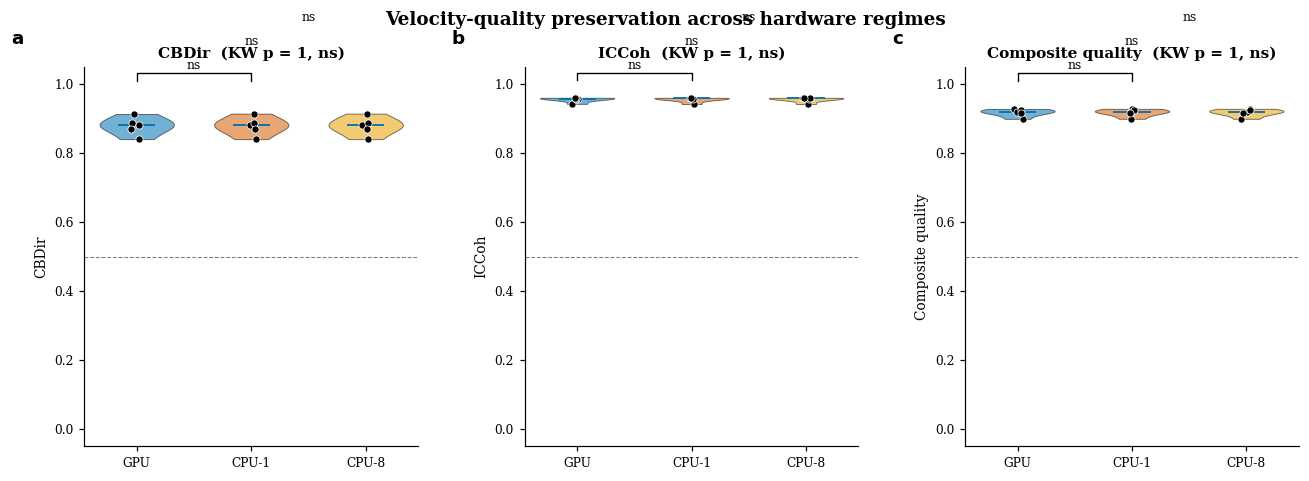

In [11]:

fig = plt.figure(figsize=(12.0, 4.6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.32,
                        left=0.06, right=0.98, top=0.88, bottom=0.13)
metrics_to_plot = [("cbdir_mean", "CBDir"),
                   ("iccoh_mean", "ICCoh"),
                   ("quality_mean", "Composite quality")]
for k, (metric, label) in enumerate(metrics_to_plot):
    ax = fig.add_subplot(gs[0, k])
    panel_label(ax, "abc"[k], x=-0.22)
    data = [bench.loc[bench["condition"].eq(c), metric].dropna().values for c in order]
    vp = ax.violinplot(data, positions=xs, widths=0.65,
                       showmedians=True, showextrema=False)
    for pc, c in zip(vp["bodies"], order):
        pc.set_facecolor(colour[c]); pc.set_edgecolor("black")
        pc.set_alpha(0.55); pc.set_linewidth(0.6)
    for i, vals in enumerate(data):
        ax.scatter(np.full(len(vals), i) + np.random.uniform(-0.05, 0.05, len(vals)),
                   vals, color="black", s=22, zorder=5,
                   edgecolor="white", linewidth=0.5)
    ax.set_xticks(xs); ax.set_xticklabels(order)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, ls="--", color="grey", lw=0.7)
    ax.set_ylabel(label)
    p_kw = stat_df.query("metric == @metric and comparison == 'omnibus KW'")["p_bh"].iloc[0]
    ax.set_title(f"{label}  (KW p = {p_kw:.2g}, {stars(p_kw)})")
    # Pairwise brackets
    yh = max(0.96, max([float(np.nanmax(d)) for d in data if len(d)] + [0.95]))
    pairs = list(combinations(range(len(order)), 2))
    for off, (i, j) in enumerate(pairs):
        sel = stat_df.query("metric == @metric and comparison == @order[@i] + ' vs ' + @order[@j]")
        if len(sel):
            q = sel["p_bh"].iloc[0]
            add_significance_bracket(ax, i, j, yh + 0.05 + off * 0.07, stars(q))

fig.suptitle("Velocity-quality preservation across hardware regimes",
             fontsize=12, fontweight="bold", y=0.99)
savefig(fig, "nb1_v3_quality_preservation")
plt.show()


## 6. Composite Figure 3 - representative velocity fields

To confirm visually that the produced velocity field is identical (up to MLP-init noise)
across regimes we re-run VelOT in-process for each regime and plot the resulting field.

In [13]:
def umap_axis(ax, pos=(0.02, 0.02), length=0.15, fontsize=9):
    x0, y0 = pos
    ax.axis("off")
    ax.annotate("", xy=(x0 + length, y0), xytext=(x0, y0),
                xycoords="axes fraction",
                arrowprops=dict(arrowstyle="->", lw=1.2, color="black"))
    ax.annotate("", xy=(x0, y0 + length), xytext=(x0, y0),
                xycoords="axes fraction",
                arrowprops=dict(arrowstyle="->", lw=1.2, color="black"))
    ax.text(x0 + length, y0 - 0.02, "UMAP1",
            transform=ax.transAxes, ha="right", va="top", fontsize=fontsize)
    ax.text(x0 - 0.02, y0 + length, "UMAP2",
            transform=ax.transAxes, ha="right", va="top",
            rotation=90, fontsize=fontsize)

  in-process VelOT for GPU…
  Using precomputed spatial labels from 'clusters_id': 3 clusters
  Built 8 window pairs across 3 clusters (skipped 0 small clusters)
  Window size: 100, step: 100
  OT velocity computed: 800 cells with velocity, 300 cells without (will be filled by smoothing)
Found torch compatible version. Running on cuda device
  Velocity projected to UMAP (1100 cells)
VelOT Velocity Metrics

Inner-Cluster Coherence (mean: 0.941):
                   Branch_1: 0.922
                   Branch_2: 0.979
                       Root: 0.921

Inner-Cluster Coherence (median: 0.946):
                   Branch_1: 0.945
                   Branch_2: 0.984
                       Root: 0.946

Cross-Boundary Correctness (mean: 0.917):
             Root → Branch_1       : 0.930
             Root → Branch_2       : 0.905
  in-process VelOT for CPU-1…
  Using precomputed spatial labels from 'clusters_id': 3 clusters
  Built 8 window pairs across 3 clusters (skipped 0 small clusters)
  Wind

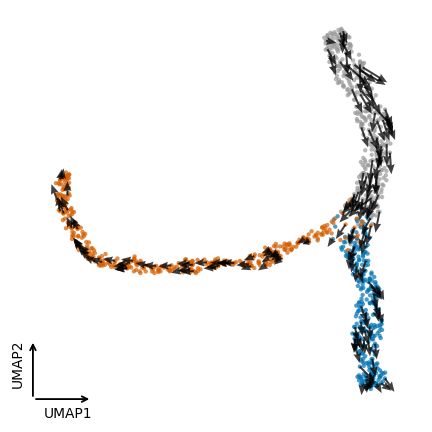

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3_threads/figures/ablation_velocity_b.{pdf,png}


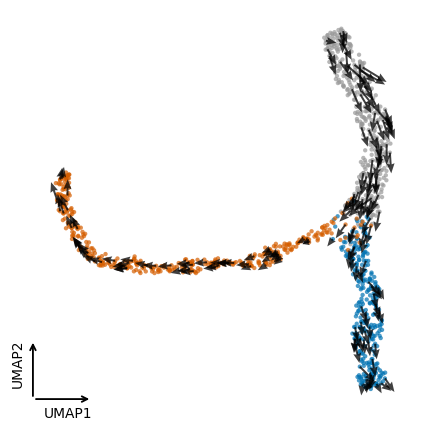

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3_threads/figures/ablation_velocity_c.{pdf,png}


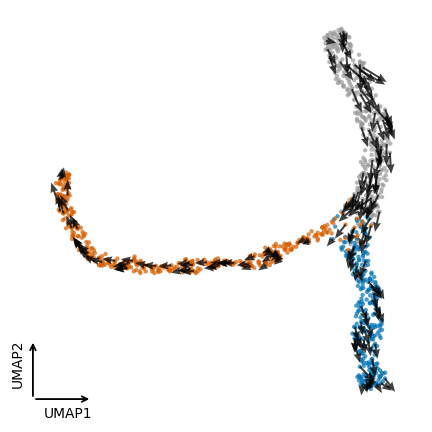

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3_threads/figures/ablation_velocity_d.{pdf,png}


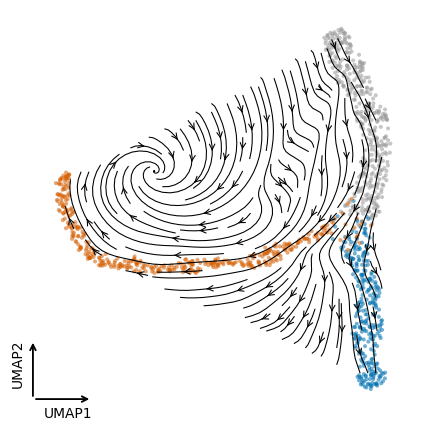

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3_threads/figures/ablation_velocity_e.{pdf,png}


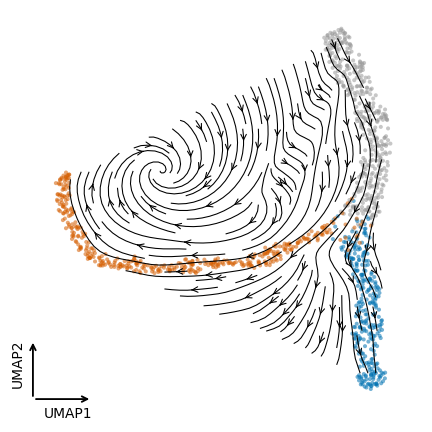

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3_threads/figures/ablation_velocity_f.{pdf,png}


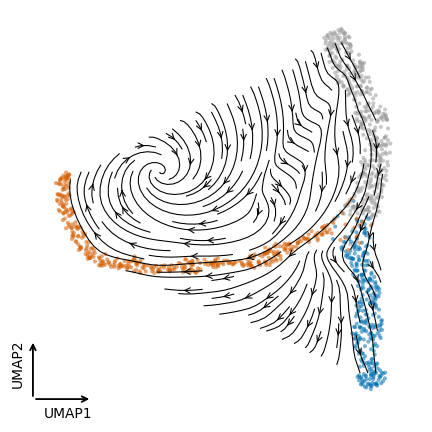

In [14]:
in_proc_fields = {}
for reg in REGIMES:
    print(f"  in-process VelOT for {reg['name']}…")
    if reg["hide_cuda"]:
        os.environ["CUDA_VISIBLE_DEVICES"] = ""
    a, _, _ = run_velot_once(name=reg["name"], seed=42, n_epochs=200)
    in_proc_fields[reg["name"]] = a

lettera = ["a", "b", "c"]
# ---------- (a) quiver panels ----------
for j, reg in enumerate(REGIMES):
    a = in_proc_fields[reg["name"]]
    fig, ax = plt.subplots(figsize=(4, 4))
    quiver_panel(ax, a, every=7, scale_mult=1, width=0.005)
    umap_axis(ax)
    plt.tight_layout()
    savefig(fig, f"ablation_velocity_{lettera[j]}")
    plt.show()

letterb = ["d", "e", "f"]
# ---------- (b) streamline panels ----------
for j, reg in enumerate(REGIMES):
    a = in_proc_fields[reg["name"]]
    fig, ax = plt.subplots(figsize=(4, 4))
    streamline_panel(ax, a, density=1.6, ngrid=46, lw=0.7)
    umap_axis(ax)
    plt.tight_layout()
    savefig(fig, f"ablation_velocity_{letterb[j]}")
    plt.show()

In [57]:
def save_legend(filename="ablation_velocity_legend", fontsize=12, markersize=12, dpi=300):
    handles = []
    for cat in TERMINALS:
        handles.append(plt.Line2D([0], [0], marker="o", color="w",
                                  markerfacecolor=ROLE.get(cat, WONG["grey"]),
                                  markersize=markersize, label=cat,
                                  markeredgecolor="black", markeredgewidth=0.4))

    fig = plt.figure(figsize=(0.1, 0.1))  # tiny, will expand with bbox_inches
    leg = fig.legend(handles=handles, loc="center",
                     fontsize=fontsize, frameon=False,
                     ncol=len(TERMINALS))

    fig.canvas.draw()
    bbox = leg.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    savefig(fig, filename)
    plt.close(fig)

save_legend()

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3_threads/figures/ablation_velocity_legend.{pdf,png}


## 7. Outputs

| File | Content |
|------|---------|
| `tables/nb1_v3_raw_timings.csv`         | one row per `(regime × seed)` measurement |
| `tables/nb1_v3_summary.csv`             | mean ± SD per regime, all stages, speed-ups and metrics |
| `tables/nb1_v3_statistical_tests.csv`   | omnibus + pairwise Kruskal–Wallis / Mann–Whitney (BH-corrected) |
| `figures/nb1_v3_master_timing.{pdf,png}`        | composite Fig. 1 (6 panels) |
| `figures/nb1_v3_quality_preservation.{pdf,png}` | composite Fig. 2 (3 panels) |
| `figures/nb1_v3_field_gallery.{pdf,png}`        | composite Fig. 3 (quiver + streamline gallery) |

## 8. Take-aways

1. **The GPU is the natural default** for the neural smoothing stage when CUDA is available.
2. **CPU-8 is now implemented as useful multi-core parallelism**, not naive global BLAS
   threading. Independent OT window pairs are parallelised, whereas BLAS is kept serial
   to avoid oversubscription on small Sinkhorn matrices.
3. **CPU-1 remains the strict serial reference**, so the speed-up panel directly reports
   whether multi-core execution improves wall-clock time without altering velocity quality.
4. **Quality preservation is checked explicitly** using CBDir, ICCoh and composite quality,
   plus representative quiver/streamline fields.
